# Multi-Dataset Standardized Training and FEI Evaluation

This notebook trains one contrastive ResNet18 on both standardized CUFSF and standardized FS2K.

Evaluation targets:

1. CUFSF test split.
2. FS2K held-out test split.
3. FEI held-out identities after AI-generated sketches are added.

FEI currently has photos only. The FEI evaluation cells expect generated sketches in:

```text
data/FEI/fei-selected-sketches
```

Sketch filenames can match either the selected photo filename stem, for example `1-11.png`, or the person id, for example `1.png`.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import os
import json
import math
import random
import re
import time

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageEnhance, ImageFilter, ImageDraw

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path('/home/tndor/Documents/Work/Classwork/semester-4/main-challenge')
DATA_ROOT = PROJECT_ROOT / 'data'

STD_ROOT = DATA_ROOT / 'processed' / 'standardized_224_neutral'
STD_CUFSF_DIR = STD_ROOT / 'cufsf'
STD_FS2K_DIR = STD_ROOT / 'fs2k'

FEI_ROOT = DATA_ROOT / 'FEI'
FEI_SELECTED_PHOTO_DIR = FEI_ROOT / 'fei-selected-set'
FEI_SKETCH_DIR = FEI_ROOT / 'fei-selected-sketches'
FEI_CENTRALIZED_GALLERY_DIR = FEI_ROOT / 'fei-centralized-set'
FEI_CONTROLLED_GALLERY_DIR = FEI_ROOT / 'fei-controlled-set'

OUTPUT_DIR = DATA_ROOT / 'outputs' / 'multidataset_standardized_resnet18'
SPLIT_DIR = OUTPUT_DIR / 'splits'
MODEL_DIR = OUTPUT_DIR / 'models'
FIGURE_DIR = OUTPUT_DIR / 'figures'
RETRIEVAL_DIR = OUTPUT_DIR / 'retrieval_examples'
PROCESSED_FEI_DIR = STD_ROOT / 'fei'
for directory in [OUTPUT_DIR, SPLIT_DIR, MODEL_DIR, FIGURE_DIR, RETRIEVAL_DIR, PROCESSED_FEI_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
BACKGROUND_VALUE = 238
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2
PIN_MEMORY = DEVICE == 'cuda'
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PROJECTION_DIM = 128
TEMPERATURE = 0.07
PATIENCE = 8

print('Device:', DEVICE)
print('Standardized CUFSF:', STD_CUFSF_DIR)
print('Standardized FS2K:', STD_FS2K_DIR)
print('FEI selected photos:', FEI_SELECTED_PHOTO_DIR)
print('Expected FEI generated sketches:', FEI_SKETCH_DIR)
print('Output dir:', OUTPUT_DIR)

/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/sketch2face/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Standardized CUFSF: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf
Standardized FS2K: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fs2k
FEI selected photos: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/FEI/fei-selected-set
Expected FEI generated sketches: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/FEI/fei-selected-sketches
Output dir: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18


## 2. Load standardized CUFSF and create frozen FS2K splits

In [2]:
def audit_pairs(df, name):
    df = df.copy()
    required = {'id', 'sketch_path', 'photo_path'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'{name} missing columns: {sorted(missing)}')
    df['id'] = df['id'].astype(str)
    df['sketch_path'] = df['sketch_path'].astype(str)
    df['photo_path'] = df['photo_path'].astype(str)
    df['sketch_exists'] = df['sketch_path'].apply(lambda p: Path(p).exists())
    df['photo_exists'] = df['photo_path'].apply(lambda p: Path(p).exists())
    print(f'[{name}] rows:', len(df))
    print(f'[{name}] unique ids:', df['id'].nunique())
    print(f'[{name}] sketches exist:', int(df['sketch_exists'].sum()), '/', len(df))
    print(f'[{name}] photos exist:', int(df['photo_exists'].sum()), '/', len(df))
    assert df['sketch_exists'].all(), f'{name}: missing sketches'
    assert df['photo_exists'].all(), f'{name}: missing photos'
    return df.drop(columns=['sketch_exists', 'photo_exists'], errors='ignore')


def namespace_ids(df, namespace):
    df = df.copy()
    raw_ids = df['id'].astype(str)
    df['raw_id'] = raw_ids
    df['id'] = raw_ids.apply(lambda value: value if value.startswith(f'{namespace}_') else f'{namespace}_{value}')
    df['dataset_source'] = namespace
    return df


cufsf_train_df = audit_pairs(pd.read_csv(STD_CUFSF_DIR / 'train_pairs.csv', dtype={'id': str}), 'CUFSF train')
cufsf_val_df = audit_pairs(pd.read_csv(STD_CUFSF_DIR / 'val_pairs.csv', dtype={'id': str}), 'CUFSF val')
cufsf_test_df = audit_pairs(pd.read_csv(STD_CUFSF_DIR / 'test_pairs.csv', dtype={'id': str}), 'CUFSF test')
fs2k_df = audit_pairs(pd.read_csv(STD_FS2K_DIR / 'fs2k_pairs.csv', dtype={'id': str}), 'FS2K all')

cufsf_train_df = namespace_ids(cufsf_train_df, 'cufsf')
cufsf_val_df = namespace_ids(cufsf_val_df, 'cufsf')
cufsf_test_df = namespace_ids(cufsf_test_df, 'cufsf')
fs2k_df = namespace_ids(fs2k_df, 'fs2k')

fs2k_train_csv = SPLIT_DIR / 'fs2k_train_pairs.csv'
fs2k_val_csv = SPLIT_DIR / 'fs2k_val_pairs.csv'
fs2k_test_csv = SPLIT_DIR / 'fs2k_test_pairs.csv'

if fs2k_train_csv.exists() and fs2k_val_csv.exists() and fs2k_test_csv.exists():
    print('Loading existing frozen FS2K splits.')
    fs2k_train_df = pd.read_csv(fs2k_train_csv, dtype={'id': str, 'raw_id': str})
    fs2k_val_df = pd.read_csv(fs2k_val_csv, dtype={'id': str, 'raw_id': str})
    fs2k_test_df = pd.read_csv(fs2k_test_csv, dtype={'id': str, 'raw_id': str})
else:
    print('Creating new frozen FS2K train/val/test splits.')
    fs2k_train_df, fs2k_temp_df = train_test_split(fs2k_df, test_size=0.30, random_state=SEED, shuffle=True)
    fs2k_val_df, fs2k_test_df = train_test_split(fs2k_temp_df, test_size=0.50, random_state=SEED, shuffle=True)
    fs2k_train_df = fs2k_train_df.reset_index(drop=True)
    fs2k_val_df = fs2k_val_df.reset_index(drop=True)
    fs2k_test_df = fs2k_test_df.reset_index(drop=True)
    fs2k_train_df.to_csv(fs2k_train_csv, index=False)
    fs2k_val_df.to_csv(fs2k_val_csv, index=False)
    fs2k_test_df.to_csv(fs2k_test_csv, index=False)
    print('Saved:', fs2k_train_csv)
    print('Saved:', fs2k_val_csv)
    print('Saved:', fs2k_test_csv)

fs2k_train_df = audit_pairs(fs2k_train_df, 'FS2K train')
fs2k_val_df = audit_pairs(fs2k_val_df, 'FS2K val')
fs2k_test_df = audit_pairs(fs2k_test_df, 'FS2K test')

combined_train_df = pd.concat([cufsf_train_df, fs2k_train_df], ignore_index=True)
combined_val_df = pd.concat([cufsf_val_df, fs2k_val_df], ignore_index=True)

print('\\nSplit sizes')
print({
    'cufsf_train': len(cufsf_train_df),
    'fs2k_train': len(fs2k_train_df),
    'combined_train': len(combined_train_df),
    'cufsf_val': len(cufsf_val_df),
    'fs2k_val': len(fs2k_val_df),
    'combined_val': len(combined_val_df),
    'cufsf_test': len(cufsf_test_df),
    'fs2k_test': len(fs2k_test_df),
})
display(combined_train_df.head())

[CUFSF train] rows: 764
[CUFSF train] unique ids: 764
[CUFSF train] sketches exist: 764 / 764
[CUFSF train] photos exist: 764 / 764
[CUFSF val] rows: 191
[CUFSF val] unique ids: 191
[CUFSF val] sketches exist: 191 / 191
[CUFSF val] photos exist: 191 / 191
[CUFSF test] rows: 239
[CUFSF test] unique ids: 239
[CUFSF test] sketches exist: 239 / 239
[CUFSF test] photos exist: 239 / 239
[FS2K all] rows: 2104
[FS2K all] unique ids: 2104
[FS2K all] sketches exist: 2104 / 2104
[FS2K all] photos exist: 2104 / 2104
Loading existing frozen FS2K splits.
[FS2K train] rows: 1472
[FS2K train] unique ids: 1472
[FS2K train] sketches exist: 1472 / 1472
[FS2K train] photos exist: 1472 / 1472
[FS2K val] rows: 316
[FS2K val] unique ids: 316
[FS2K val] sketches exist: 316 / 316
[FS2K val] photos exist: 316 / 316
[FS2K test] rows: 316
[FS2K test] unique ids: 316
[FS2K test] sketches exist: 316 / 316
[FS2K test] photos exist: 316 / 316
\nSplit sizes
{'cufsf_train': 764, 'fs2k_train': 1472, 'combined_train': 22

,id,dataset,sketch_path,photo_path,feret_basename,source_sketch_path,source_photo_path,standardization,raw_id,dataset_source,group
0,cufsf_01095,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,01095ba010_960521,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,224_gray_neutral_oval_mask,01095,cufsf,NaN
1,cufsf_00202,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00202fa010_940128,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,224_gray_neutral_oval_mask,00202,cufsf,NaN
2,cufsf_00257,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00257fa010_940128,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,224_gray_neutral_oval_mask,00257,cufsf,NaN
3,cufsf_00295,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00295fa010_940422,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,224_gray_neutral_oval_mask,00295,cufsf,NaN
4,cufsf_00476,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00476fa010_940519,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,224_gray_neutral_oval_mask,00476,cufsf,NaN


## 3. Visual sanity check

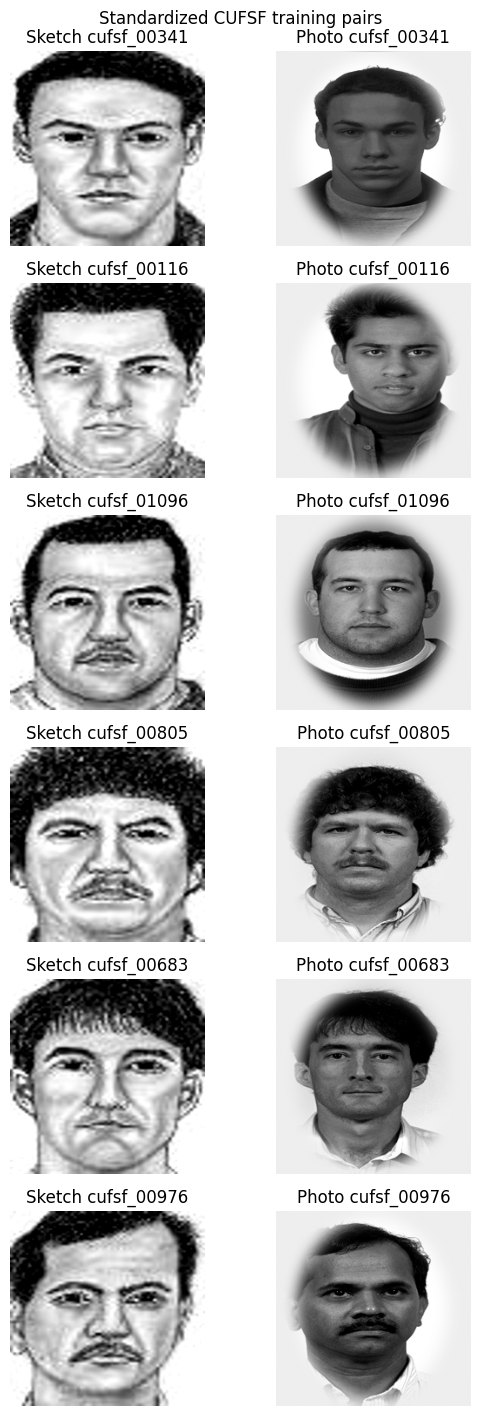

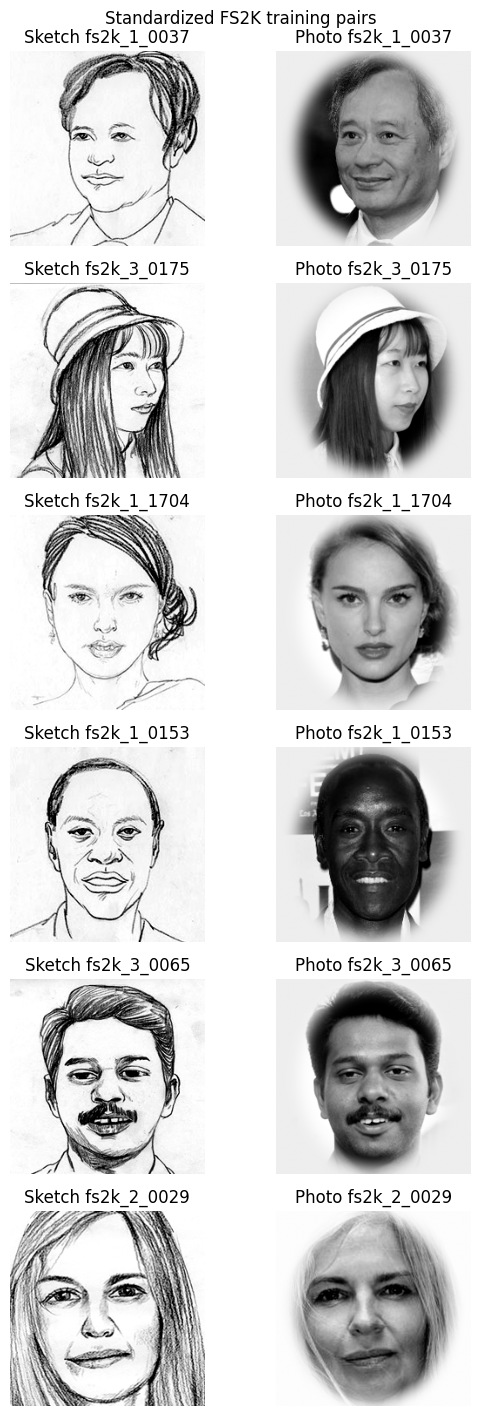

In [3]:
def show_pairs(df, n=6, seed=42, title='Pairs'):
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample), 2, figsize=(6, 2.4 * len(sample)))
    if len(sample) == 1:
        axes = np.array([axes])
    for i, row in sample.iterrows():
        axes[i, 0].imshow(Image.open(row['sketch_path']).convert('L'), cmap='gray')
        axes[i, 0].set_title(f"Sketch {row['id']}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(Image.open(row['photo_path']).convert('L'), cmap='gray')
        axes[i, 1].set_title(f"Photo {row['id']}")
        axes[i, 1].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_pairs(cufsf_train_df, title='Standardized CUFSF training pairs')
show_pairs(fs2k_train_df, title='Standardized FS2K training pairs')

## 4. Dataset, model, and retrieval helpers

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.10, contrast=0.10)], p=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SketchPhotoPairDataset(Dataset):
    def __init__(self, pairs_df, transform):
        self.df = pairs_df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sketch = Image.open(row['sketch_path']).convert('RGB')
        photo = Image.open(row['photo_path']).convert('RGB')
        return {
            'id': str(row['id']),
            'sketch': self.transform(sketch),
            'photo': self.transform(photo),
            'sketch_path': row['sketch_path'],
            'photo_path': row['photo_path'],
        }


def make_loader(df, transform, shuffle=False, drop_last=False):
    return DataLoader(
        SketchPhotoPairDataset(df, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=drop_last,
    )


class ResNet18ProjectionEncoder(nn.Module):
    def __init__(self, projection_dim=128, pretrained=True):
        super().__init__()
        if pretrained:
            try:
                weights = models.ResNet18_Weights.DEFAULT
                backbone = models.resnet18(weights=weights)
                print('Loaded ImageNet pretrained ResNet18 weights.')
            except Exception as exc:
                print('Could not load pretrained weights; using random initialization.')
                print('Reason:', repr(exc))
                backbone = models.resnet18(weights=None)
        else:
            backbone = models.resnet18(weights=None)

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feature_dim, projection_dim),
        )

    def forward(self, x):
        features = self.backbone(x)
        projected = self.projection(features)
        return F.normalize(projected, p=2, dim=1)


def symmetric_contrastive_loss(sketch_embeddings, photo_embeddings, temperature=0.07):
    logits = (sketch_embeddings @ photo_embeddings.T) / temperature
    targets = torch.arange(logits.size(0), device=logits.device)
    return (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2


def evaluate_similarity_matrix(similarity, query_ids, gallery_ids, ks=(1, 5, 10)):
    query_ids = list(query_ids)
    gallery_ids = list(gallery_ids)
    gallery_id_to_index = {gid: idx for idx, gid in enumerate(gallery_ids)}
    ranks = []
    for i, qid in enumerate(query_ids):
        correct_idx = gallery_id_to_index[qid]
        ranked_indices = np.argsort(-similarity[i])
        rank = int(np.where(ranked_indices == correct_idx)[0][0]) + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    metrics = {f'Recall@{k}': float(np.mean(ranks <= k)) for k in ks}
    metrics['MRR'] = float(np.mean(1.0 / ranks))
    metrics['MeanRank'] = float(np.mean(ranks))
    metrics['MedianRank'] = float(np.median(ranks))
    return metrics, ranks


@torch.no_grad()
def encode_pair_loader(model, loader, device):
    model.eval()
    sketch_embeddings = []
    photo_embeddings = []
    ids = []
    for batch in tqdm(loader, desc='Encoding', leave=False):
        sketches = batch['sketch'].to(device, non_blocking=True)
        photos = batch['photo'].to(device, non_blocking=True)
        sketch_embeddings.append(model(sketches).cpu())
        photo_embeddings.append(model(photos).cpu())
        ids.extend([str(x) for x in batch['id']])
    return ids, torch.cat(sketch_embeddings).numpy(), torch.cat(photo_embeddings).numpy()


def evaluate_retrieval_split(model, loader, name, device=DEVICE):
    ids, sketch_embeddings, photo_embeddings = encode_pair_loader(model, loader, device)
    similarity = sketch_embeddings @ photo_embeddings.T
    metrics, ranks = evaluate_similarity_matrix(similarity, ids, ids)
    print(f'\\n{name}')
    print('-' * len(name))
    for key, value in metrics.items():
        if key.startswith('Recall') or key == 'MRR':
            print(f'{key}: {value:.4f}')
        else:
            print(f'{key}: {value:.2f}')
    return metrics, ranks, similarity, ids

## 5. Train on CUFSF + FS2K

In [5]:
train_loader = make_loader(combined_train_df, train_transform, shuffle=True, drop_last=True)
cufsf_val_loader = make_loader(cufsf_val_df, eval_transform)
fs2k_val_loader = make_loader(fs2k_val_df, eval_transform)
combined_val_loader = make_loader(combined_val_df, eval_transform)
cufsf_test_loader = make_loader(cufsf_test_df, eval_transform)
fs2k_test_loader = make_loader(fs2k_test_df, eval_transform)

model = ResNet18ProjectionEncoder(projection_dim=PROJECTION_DIM, pretrained=True).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_one_epoch(model, loader):
    model.train()
    losses = []
    for batch in tqdm(loader, desc='Training', leave=False):
        sketches = batch['sketch'].to(DEVICE, non_blocking=True)
        photos = batch['photo'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        sketch_embeddings = model(sketches)
        photo_embeddings = model(photos)
        loss = symmetric_contrastive_loss(sketch_embeddings, photo_embeddings, TEMPERATURE)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses))


history = []
best_score = -math.inf
best_epoch = -1
epochs_without_improvement = 0
best_model_path = MODEL_DIR / 'best_multidataset_standardized_resnet18.pt'

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader)
    cufsf_val_metrics, _, _, _ = evaluate_retrieval_split(model, cufsf_val_loader, f'CUFSF validation epoch {epoch}')
    fs2k_val_metrics, _, _, _ = evaluate_retrieval_split(model, fs2k_val_loader, f'FS2K validation epoch {epoch}')
    combined_val_metrics, _, _, _ = evaluate_retrieval_split(model, combined_val_loader, f'Combined validation epoch {epoch}')
    scheduler.step()

    selection_score = (cufsf_val_metrics['MRR'] + fs2k_val_metrics['MRR']) / 2
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'lr': optimizer.param_groups[0]['lr'],
        'seconds': time.time() - start,
        'selection_avg_mrr': selection_score,
        **{f'cufsf_val_{key}': value for key, value in cufsf_val_metrics.items()},
        **{f'fs2k_val_{key}': value for key, value in fs2k_val_metrics.items()},
        **{f'combined_val_{key}': value for key, value in combined_val_metrics.items()},
    }
    history.append(row)

    if selection_score > best_score:
        best_score = selection_score
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': {
                'image_size': IMAGE_SIZE,
                'batch_size': BATCH_SIZE,
                'epochs': EPOCHS,
                'learning_rate': LEARNING_RATE,
                'weight_decay': WEIGHT_DECAY,
                'projection_dim': PROJECTION_DIM,
                'temperature': TEMPERATURE,
                'train_datasets': ['standardized_cufsf', 'standardized_fs2k'],
                'selection_metric': 'average of CUFSF val MRR and FS2K val MRR',
            },
            'cufsf_val_metrics': cufsf_val_metrics,
            'fs2k_val_metrics': fs2k_val_metrics,
            'combined_val_metrics': combined_val_metrics,
        }, best_model_path)
        print('Saved new best:', best_model_path)
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | loss={train_loss:.4f} | "
        f"avg_val_mrr={selection_score:.4f} | best_epoch={best_epoch} | "
        f"time={row['seconds']:.1f}s"
    )
    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping after {PATIENCE} epochs without improvement.')
        break

history_df = pd.DataFrame(history)
history_csv = OUTPUT_DIR / 'multidataset_training_history.csv'
history_df.to_csv(history_csv, index=False)
print('Best epoch:', best_epoch)
print('Best average validation MRR:', best_score)
print('Saved:', history_csv)
display(history_df.tail())

Loaded ImageNet pretrained ResNet18 weights.


\nCUFSF validation epoch 1
------------------------
Recall@1: 0.1361
Recall@5: 0.4241
Recall@10: 0.5654
MRR: 0.2853
MeanRank: 14.31
MedianRank: 8.00


\nFS2K validation epoch 1
-----------------------
Recall@1: 0.3639
Recall@5: 0.6171
Recall@10: 0.7468
MRR: 0.4856
MeanRank: 10.59
MedianRank: 3.00


\nCombined validation epoch 1
---------------------------
Recall@1: 0.2761
Recall@5: 0.5385
Recall@10: 0.6706
MRR: 0.4041
MeanRank: 13.61
MedianRank: 4.00
Saved new best: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18/models/best_multidataset_standardized_resnet18.pt
Epoch 001/25 | loss=1.1612 | avg_val_mrr=0.3854 | best_epoch=1 | time=142.6s


\nCUFSF validation epoch 2
------------------------
Recall@1: 0.2461
Recall@5: 0.5812
Recall@10: 0.7277
MRR: 0.4043
MeanRank: 9.66
MedianRank: 4.00


...

\nCombined validation epoch 24
----------------------------
Recall@1: 0.5424
Recall@5: 0.8067
Recall@10: 0.8718
MRR: 0.6615
MeanRank: 5.89
MedianRank: 1.00
Epoch 024/25 | loss=0.0121 | avg_val_mrr=0.6549 | best_epoch=17 | time=166.9s


\nCUFSF validation epoch 25
-------------------------
Recall@1: 0.4188
Recall@5: 0.7016
Recall@10: 0.8482
MRR: 0.5540
MeanRank: 5.42
MedianRank: 2.00


\nFS2K validation epoch 25
------------------------
Recall@1: 0.6677
Recall@5: 0.9146
Recall@10: 0.9589
MRR: 0.7763
MeanRank: 2.95
MedianRank: 1.00


\nCombined validation epoch 25
----------------------------
Recall@1: 0.5503
Recall@5: 0.8126
Recall@10: 0.9034
MRR: 0.6709
MeanRank: 5.26
MedianRank: 1.00
Epoch 025/25 | loss=0.0126 | avg_val_mrr=0.6651 | best_epoch=17 | time=149.4s
Early stopping after 8 epochs without improvement.
Best epoch: 17
Best average validation MRR: 0.6679151251386821
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18/multidataset_training_history.csv


,epoch,train_loss,lr,seconds,selection_avg_mrr,cufsf_val_Recall@1,cufsf_val_Recall@5,cufsf_val_Recall@10,cufsf_val_MRR,cufsf_val_MeanRank,...,fs2k_val_Recall@10,fs2k_val_MRR,fs2k_val_MeanRank,fs2k_val_MedianRank,combined_val_Recall@1,combined_val_Recall@5,combined_val_Recall@10,combined_val_MRR,combined_val_MeanRank,combined_val_MedianRank
20,21,0.013285,6.184666e-06,170.472668,0.653232,0.397906,0.696335,0.837696,0.534047,5.670157,...,0.955696,0.772417,3.006329,1.0,0.542406,0.816568,0.879684,0.660722,5.579882,1.0
21,22,0.011971,3.511176e-06,172.859040,0.666285,0.418848,0.670157,0.827225,0.544848,5.863874,...,0.955696,0.787722,2.901899,1.0,0.564103,0.798817,0.877712,0.674177,5.617357,1.0
22,23,0.011938,1.570842e-06,173.873463,0.656204,0.397906,0.649215,0.827225,0.530957,6.068063,...,0.962025,0.781452,2.917722,1.0,0.544379,0.798817,0.879684,0.663543,5.796844,1.0
23,24,0.012144,3.942649e-07,166.930213,0.654936,0.397906,0.685864,0.821990,0.531667,6.094241,...,0.958861,0.778205,2.949367,1.0,0.542406,0.806706,0.871795,0.661539,5.893491,1.0
24,25,0.012648,0.000000e+00,149.425997,0.665115,0.418848,0.701571,0.848168,0.553979,5.424084,...,0.958861,0.776251,2.946203,1.0,0.550296,0.812623,0.903353,0.670858,5.264300,1.0


## 6. Curves

NameError: name 'history_df' is not defined

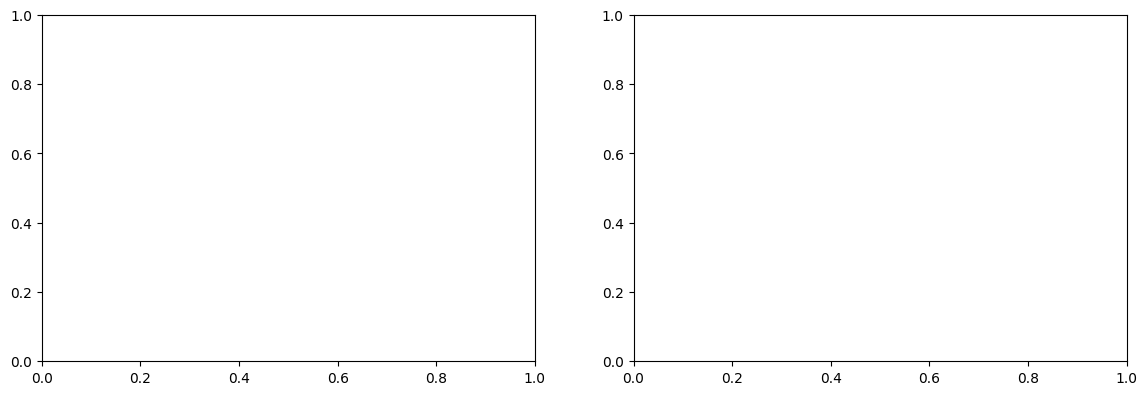

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o')
axes[0].set_title('Multi-dataset training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive loss')
axes[0].grid(True, alpha=0.3)

for metric in ['cufsf_val_MRR', 'fs2k_val_MRR', 'combined_val_MRR', 'selection_avg_mrr']:
    axes[1].plot(history_df['epoch'], history_df[metric], marker='o', label=metric)
axes[1].set_title('Validation MRR curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MRR')
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
curve_path = FIGURE_DIR / 'multidataset_training_curves.png'
fig.savefig(curve_path, dpi=150, bbox_inches='tight')
print('Saved:', curve_path)
plt.show()

## 7. Test on CUFSF and FS2K

In [ ]:

# This cell can be run after a kernel restart without rerunning training.
# If the training cell was skipped, load the saved best checkpoint path directly.
if 'best_model_path' not in globals():
    best_model_path = MODEL_DIR / 'best_multidataset_standardized_resnet18.pt'
    print('Using saved best model path:', best_model_path)


def namespace_ids_for_eval(df, namespace):
    df = df.copy()
    raw_ids = df['id'].astype(str)
    if 'raw_id' not in df.columns:
        df['raw_id'] = raw_ids
    df['id'] = raw_ids.apply(lambda value: value if value.startswith(f'{namespace}_') else f'{namespace}_{value}')
    df['dataset_source'] = namespace
    return df


def load_cufsf_test_for_eval():
    df = pd.read_csv(STD_CUFSF_DIR / 'test_pairs.csv', dtype={'id': str})
    return namespace_ids_for_eval(df, 'cufsf')


def load_fs2k_test_for_eval():
    fs2k_test_csv = SPLIT_DIR / 'fs2k_test_pairs.csv'
    if fs2k_test_csv.exists():
        return pd.read_csv(fs2k_test_csv, dtype={'id': str, 'raw_id': str})

    print('Frozen FS2K test split not found; recreating deterministic FS2K split.')
    fs2k_df = pd.read_csv(STD_FS2K_DIR / 'fs2k_pairs.csv', dtype={'id': str})
    fs2k_df = namespace_ids_for_eval(fs2k_df, 'fs2k')
    fs2k_train_df, fs2k_temp_df = train_test_split(fs2k_df, test_size=0.30, random_state=SEED, shuffle=True)
    fs2k_val_df, fs2k_test_df = train_test_split(fs2k_temp_df, test_size=0.50, random_state=SEED, shuffle=True)
    SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    fs2k_train_df.reset_index(drop=True).to_csv(SPLIT_DIR / 'fs2k_train_pairs.csv', index=False)
    fs2k_val_df.reset_index(drop=True).to_csv(SPLIT_DIR / 'fs2k_val_pairs.csv', index=False)
    fs2k_test_df = fs2k_test_df.reset_index(drop=True)
    fs2k_test_df.to_csv(fs2k_test_csv, index=False)
    print('Saved recreated FS2K test split:', fs2k_test_csv)
    return fs2k_test_df


if 'cufsf_test_df' not in globals():
    cufsf_test_df = load_cufsf_test_for_eval()
    print('Loaded CUFSF test pairs:', len(cufsf_test_df))

if 'fs2k_test_df' not in globals():
    fs2k_test_df = load_fs2k_test_for_eval()
    print('Loaded FS2K test pairs:', len(fs2k_test_df))

if 'cufsf_test_loader' not in globals():
    cufsf_test_loader = make_loader(cufsf_test_df, eval_transform)
    print('Created CUFSF test loader.')

if 'fs2k_test_loader' not in globals():
    fs2k_test_loader = make_loader(fs2k_test_df, eval_transform)
    print('Created FS2K test loader.')

def load_checkpoint(path, projection_dim=PROJECTION_DIM, device=DEVICE):
    eval_model = ResNet18ProjectionEncoder(projection_dim=projection_dim, pretrained=False).to(device)
    checkpoint = torch.load(path, map_location=device)
    eval_model.load_state_dict(checkpoint['model_state_dict'])
    eval_model.eval()
    print('Loaded checkpoint:', path)
    print('Checkpoint epoch:', checkpoint.get('epoch'))
    return eval_model, checkpoint


best_model, best_checkpoint = load_checkpoint(best_model_path)

cufsf_test_metrics, cufsf_test_ranks, cufsf_test_similarity, _ = evaluate_retrieval_split(
    best_model, cufsf_test_loader, 'Multi-dataset model on CUFSF test'
)
fs2k_test_metrics, fs2k_test_ranks, fs2k_test_similarity, _ = evaluate_retrieval_split(
    best_model, fs2k_test_loader, 'Multi-dataset model on FS2K held-out test'
)

test_results = pd.DataFrame([
    {'split': 'CUFSF test', 'method': 'Multi-dataset standardized ResNet18', **cufsf_test_metrics},
    {'split': 'FS2K held-out test', 'method': 'Multi-dataset standardized ResNet18', **fs2k_test_metrics},
])
test_results_csv = OUTPUT_DIR / 'multidataset_cufsf_fs2k_test_results.csv'
test_results.to_csv(test_results_csv, index=False)
print('Saved:', test_results_csv)
display(test_results)

## 8. Retrieval visualizations for CUFSF and FS2K

In [7]:
def make_retrieval_grid(df, similarity, ranks, method_name, n_examples=8, top_k=5, seed=42, save_path=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(df), size=min(n_examples, len(df)), replace=False)
    fig, axes = plt.subplots(len(indices), 2 + top_k, figsize=(2.15 * (2 + top_k), 2.45 * len(indices)))
    if len(indices) == 1:
        axes = np.array([axes])
    for row_i, query_idx in enumerate(indices):
        query = df.iloc[query_idx]
        ranked = np.argsort(-similarity[query_idx])[:top_k]
        axes[row_i, 0].imshow(Image.open(query['sketch_path']).convert('L'), cmap='gray')
        axes[row_i, 0].set_title(f"Query\\n{query['id']}")
        axes[row_i, 0].axis('off')
        axes[row_i, 1].imshow(Image.open(query['photo_path']).convert('L'), cmap='gray')
        axes[row_i, 1].set_title(f"Correct\\nRank {ranks[query_idx]}")
        axes[row_i, 1].axis('off')
        for j, gallery_idx in enumerate(ranked):
            item = df.iloc[gallery_idx]
            score = similarity[query_idx, gallery_idx]
            is_correct = str(item['id']) == str(query['id'])
            title = f"Top {j + 1}\\n{item['id']}\\n{score:.2f}"
            if is_correct:
                title += '\\nMATCH'
            axes[row_i, 2 + j].imshow(Image.open(item['photo_path']).convert('L'), cmap='gray')
            axes[row_i, 2 + j].set_title(title)
            axes[row_i, 2 + j].axis('off')
    fig.suptitle(method_name, fontsize=15)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Saved:', save_path)
    plt.show()

make_retrieval_grid(
    cufsf_test_df,
    cufsf_test_similarity,
    cufsf_test_ranks,
    'Multi-dataset model CUFSF test top-5',
    save_path=RETRIEVAL_DIR / 'multidataset_cufsf_test_top5.png',
)
make_retrieval_grid(
    fs2k_test_df,
    fs2k_test_similarity,
    fs2k_test_ranks,
    'Multi-dataset model FS2K held-out test top-5',
    save_path=RETRIEVAL_DIR / 'multidataset_fs2k_test_top5.png',
)

NameError: name 'cufsf_test_similarity' is not defined

## 9. FEI standardization helpers

In [8]:
def content_bbox(gray, threshold=245, pad_ratio=0.18):
    arr = np.asarray(gray)
    mask = arr < threshold
    if mask.sum() < 50:
        return None
    ys, xs = np.where(mask)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    w = x1 - x0 + 1
    h = y1 - y0 + 1
    pad = int(max(w, h) * pad_ratio)
    return (
        max(0, x0 - pad),
        max(0, y0 - pad),
        min(gray.width, x1 + pad),
        min(gray.height, y1 + pad),
    )


def square_crop_box(image, bbox=None):
    w, h = image.size
    if bbox is None:
        side = min(w, h)
        x0 = (w - side) // 2
        y0 = (h - side) // 2
        return x0, y0, x0 + side, y0 + side
    x0, y0, x1, y1 = bbox
    side = max(x1 - x0, y1 - y0)
    cx = (x0 + x1) / 2
    cy = (y0 + y1) / 2
    x0 = int(round(cx - side / 2))
    y0 = int(round(cy - side / 2))
    x1 = x0 + side
    y1 = y0 + side
    if x0 < 0:
        x1 -= x0
        x0 = 0
    if y0 < 0:
        y1 -= y0
        y0 = 0
    if x1 > w:
        x0 -= x1 - w
        x1 = w
    if y1 > h:
        y0 -= y1 - h
        y1 = h
    return max(0, x0), max(0, y0), min(w, x1), min(h, y1)


def oval_mask(size, blur=8, x_margin=0.12, y_margin=0.04):
    w, h = size
    mask = Image.new('L', size, 0)
    draw = ImageDraw.Draw(mask)
    box = (
        int(w * x_margin),
        int(h * y_margin),
        int(w * (1 - x_margin)),
        int(h * (1 - y_margin)),
    )
    draw.ellipse(box, fill=255)
    return mask.filter(ImageFilter.GaussianBlur(blur))


def standardize_image(path, kind, image_size=224, background_value=238):
    original = Image.open(path).convert('RGB')
    gray = ImageOps.grayscale(original)
    bbox = content_bbox(gray, threshold=245, pad_ratio=0.20 if kind == 'sketch' else 0.10)
    crop = original.crop(square_crop_box(original, bbox))
    crop = ImageOps.fit(crop, (image_size, image_size), method=Image.Resampling.BICUBIC, centering=(0.5, 0.45))
    crop_gray = ImageOps.grayscale(crop)
    crop_gray = ImageOps.autocontrast(crop_gray, cutoff=1)

    if kind == 'photo':
        crop_gray = ImageEnhance.Contrast(crop_gray).enhance(1.08)
        background = Image.new('L', crop_gray.size, background_value)
        return Image.composite(crop_gray, background, oval_mask(crop_gray.size))

    return ImageEnhance.Contrast(crop_gray).enhance(1.15)

## 10. Build FEI query and full-gallery tables

The FEI evaluation is asymmetric:

- Queries: the 20 AI-generated sketches from `fei-selected-sketches`.
- Gallery: all 150 FEI photos from the chosen gallery folder.
- Correct match: same FEI person id.

This is harder and more honest than the previous 20-query / 20-gallery setup.

In [9]:
def person_id_from_filename(path):
    match = re.match(r'^(\d+)', Path(path).stem)
    return int(match.group(1)) if match else None


def find_generated_sketch(person_id, selected_photo_stem, sketch_dir):
    candidates = []
    for suffix in ['.png', '.jpg', '.jpeg', '.webp']:
        candidates.append(sketch_dir / f'{selected_photo_stem}{suffix}')
        candidates.append(sketch_dir / f'{person_id}{suffix}')
    for candidate in candidates:
        if candidate.exists():
            return candidate
    all_images = [p for p in sketch_dir.glob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.webp'}]
    for path in all_images:
        if person_id_from_filename(path) == person_id:
            return path
    return None


def gallery_path_from_manifest_row(row):
    for column in ['centralized_path', 'controlled_path', 'selected_path', 'photo_path']:
        if column in row and pd.notna(row[column]):
            return Path(row[column])
    raise ValueError(f'No usable gallery path column in row: {row.to_dict()}')


def build_fei_eval_tables(gallery_dir, gallery_name, force_reprocess=False):
    if not FEI_SKETCH_DIR.exists():
        print('FEI generated sketch directory not found yet:', FEI_SKETCH_DIR)
        print('Create it and place generated sketches there, then rerun this cell.')
        return None

    gallery_manifest = gallery_dir / 'manifest.csv'
    selected_manifest = FEI_SELECTED_PHOTO_DIR / 'manifest.csv'
    if not gallery_manifest.exists():
        raise FileNotFoundError(gallery_manifest)
    if not selected_manifest.exists():
        raise FileNotFoundError(selected_manifest)

    gallery_manifest_df = pd.read_csv(gallery_manifest)
    selected_df = pd.read_csv(selected_manifest)

    out_dir = PROCESSED_FEI_DIR / gallery_name
    sketch_out_dir = out_dir / 'queries'
    photo_out_dir = out_dir / 'gallery'
    sketch_out_dir.mkdir(parents=True, exist_ok=True)
    photo_out_dir.mkdir(parents=True, exist_ok=True)

    gallery_rows = []
    for _, row in gallery_manifest_df.iterrows():
        person_id = int(row['person_id'])
        item_id = f'fei_{person_id:03d}'
        source_photo_path = gallery_path_from_manifest_row(row)
        if not source_photo_path.exists():
            raise FileNotFoundError(source_photo_path)

        photo_out = photo_out_dir / f'{item_id}.png'
        if force_reprocess or not photo_out.exists():
            standardize_image(source_photo_path, 'photo', IMAGE_SIZE, BACKGROUND_VALUE).save(photo_out)

        gallery_rows.append({
            'id': item_id,
            'raw_id': str(person_id),
            'dataset_source': f'fei_{gallery_name}',
            'photo_path': str(photo_out),
            'source_photo_path': str(source_photo_path),
            'gallery_filename': source_photo_path.name,
        })

    query_rows = []
    missing_queries = []
    for _, row in selected_df.iterrows():
        person_id = int(row['person_id'])
        item_id = f'fei_{person_id:03d}'
        selected_photo_stem = Path(row['filename']).stem
        sketch_path = find_generated_sketch(person_id, selected_photo_stem, FEI_SKETCH_DIR)
        if sketch_path is None:
            missing_queries.append({'person_id': person_id, 'selected_photo_filename': row['filename']})
            continue

        sketch_out = sketch_out_dir / f'{item_id}.png'
        if force_reprocess or not sketch_out.exists():
            standardize_image(sketch_path, 'sketch', IMAGE_SIZE, BACKGROUND_VALUE).save(sketch_out)

        query_rows.append({
            'id': item_id,
            'raw_id': str(person_id),
            'dataset_source': f'fei_{gallery_name}',
            'sketch_path': str(sketch_out),
            'source_sketch_path': str(sketch_path),
            'selected_photo_filename': row['filename'],
        })

    if missing_queries:
        print('Missing FEI generated sketches:', missing_queries)

    query_df = pd.DataFrame(query_rows)
    gallery_df = pd.DataFrame(gallery_rows).sort_values('id').reset_index(drop=True)

    if len(query_df) == 0:
        print('No FEI query sketches built. Check generated sketch filenames.')
        return None

    query_csv = out_dir / 'query_sketches.csv'
    gallery_csv = out_dir / 'gallery_photos.csv'
    query_df.to_csv(query_csv, index=False)
    gallery_df.to_csv(gallery_csv, index=False)

    print('Saved:', query_csv)
    print('Saved:', gallery_csv)
    print(f'FEI {gallery_name} queries:', len(query_df))
    print(f'FEI {gallery_name} gallery photos:', len(gallery_df))
    print('All query ids present in gallery:', set(query_df['id']).issubset(set(gallery_df['id'])))
    display(query_df.head())
    display(gallery_df.head())

    return {
        'name': gallery_name,
        'query_df': query_df,
        'gallery_df': gallery_df,
        'query_csv': query_csv,
        'gallery_csv': gallery_csv,
    }


fei_centralized_eval = build_fei_eval_tables(FEI_CENTRALIZED_GALLERY_DIR, 'centralized_gallery')
fei_controlled_eval = build_fei_eval_tables(FEI_CONTROLLED_GALLERY_DIR, 'controlled_orientation_13_gallery')

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fei/centralized_gallery/query_sketches.csv
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fei/centralized_gallery/gallery_photos.csv
FEI centralized_gallery queries: 20
FEI centralized_gallery gallery photos: 200
All query ids present in gallery: True


,id,raw_id,dataset_source,sketch_path,source_sketch_path,selected_photo_filename
0,fei_001,1,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,1-11.jpg
1,fei_008,8,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,8-13.jpg
2,fei_015,15,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,15-11.jpg
3,fei_022,22,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,22-13.jpg
4,fei_029,29,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,29-11.jpg


,id,raw_id,dataset_source,photo_path,source_photo_path,gallery_filename
0,fei_001,1,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,1-06.jpg
1,fei_002,2,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,2-06.jpg
2,fei_003,3,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,3-13.jpg
3,fei_004,4,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,4-11.jpg
4,fei_005,5,fei_centralized_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,5-06.jpg


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fei/controlled_orientation_13_gallery/query_sketches.csv
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fei/controlled_orientation_13_gallery/gallery_photos.csv
FEI controlled_orientation_13_gallery queries: 20
FEI controlled_orientation_13_gallery gallery photos: 200
All query ids present in gallery: True


,id,raw_id,dataset_source,sketch_path,source_sketch_path,selected_photo_filename
0,fei_001,1,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,1-11.jpg
1,fei_008,8,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,8-13.jpg
2,fei_015,15,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,15-11.jpg
3,fei_022,22,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,22-13.jpg
4,fei_029,29,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,29-11.jpg


,id,raw_id,dataset_source,photo_path,source_photo_path,gallery_filename
0,fei_001,1,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,1-13.jpg
1,fei_002,2,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,2-13.jpg
2,fei_003,3,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,3-13.jpg
3,fei_004,4,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,4-13.jpg
4,fei_005,5,fei_controlled_orientation_13_gallery,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,5-13.jpg


## 11. Evaluate FEI as 20 sketch queries against 150-photo galleries

This cell ranks each of the 20 generated FEI sketches against all 150 FEI gallery photos.

Loaded previous CUFSF/FS2K test results: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18/multidataset_cufsf_fs2k_test_results.csv



Multi-dataset model on FEI centralized full 150-photo gallery
-------------------------------------------------------------
Queries: 20
Gallery photos: 200
Recall@1: 0.1000
Recall@5: 0.4000
Recall@10: 0.5000
MRR: 0.2192
MeanRank: 30.95
MedianRank: 11.00
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18/retrieval_examples/fei_centralized_full150_gallery_top5.png


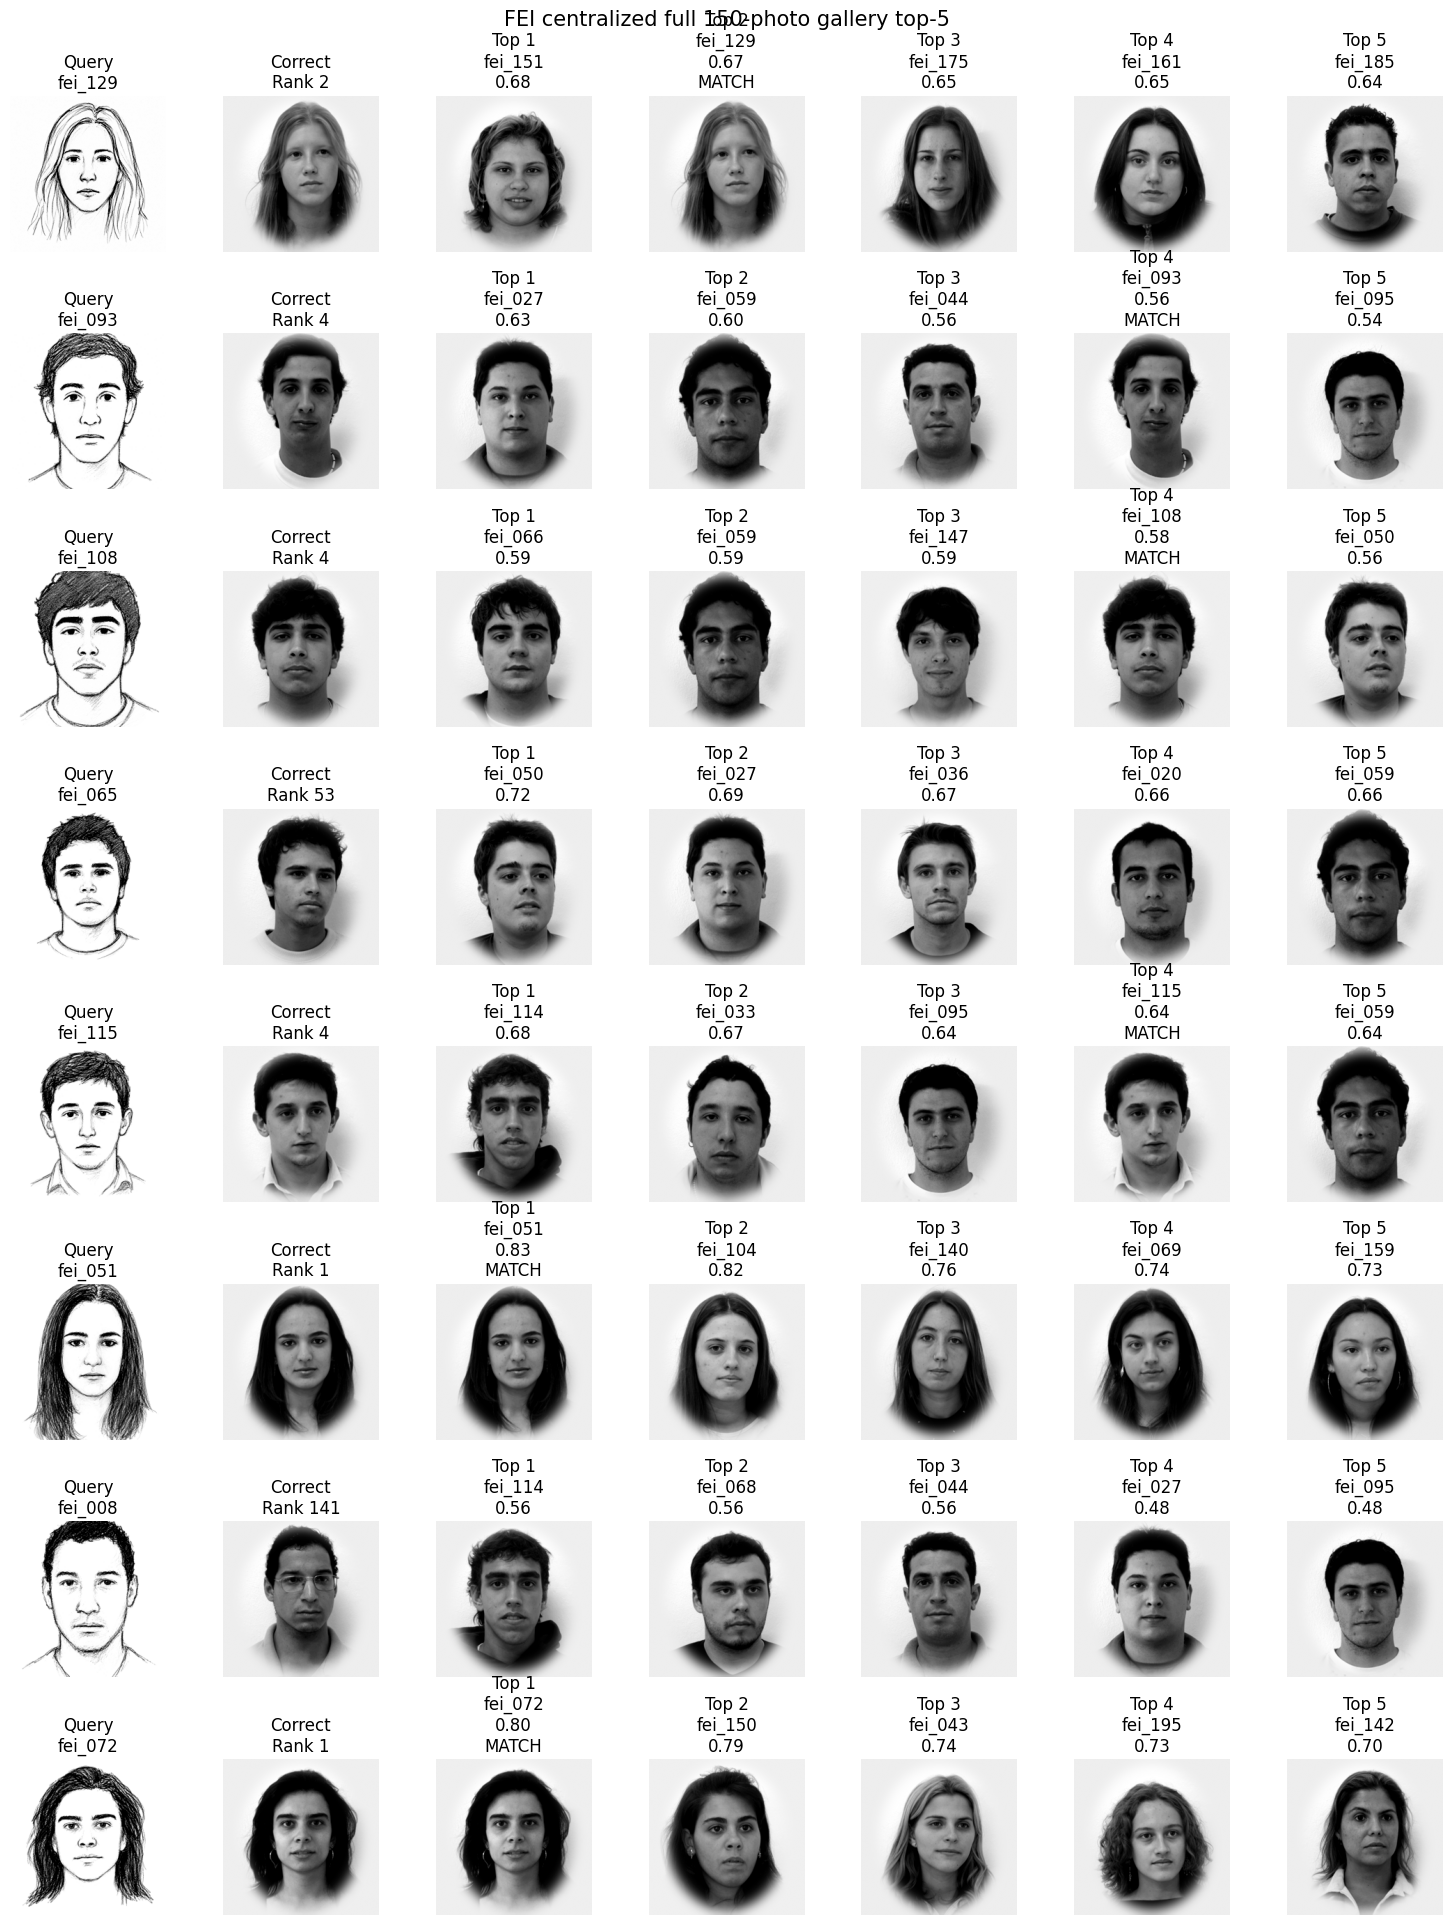


Multi-dataset model on FEI controlled orientation-13 full 150-photo gallery
---------------------------------------------------------------------------
Queries: 20
Gallery photos: 200
Recall@1: 0.2500
Recall@5: 0.4000
Recall@10: 0.6000
MRR: 0.3429
MeanRank: 19.80
MedianRank: 8.00
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18/retrieval_examples/fei_controlled_full150_gallery_top5.png


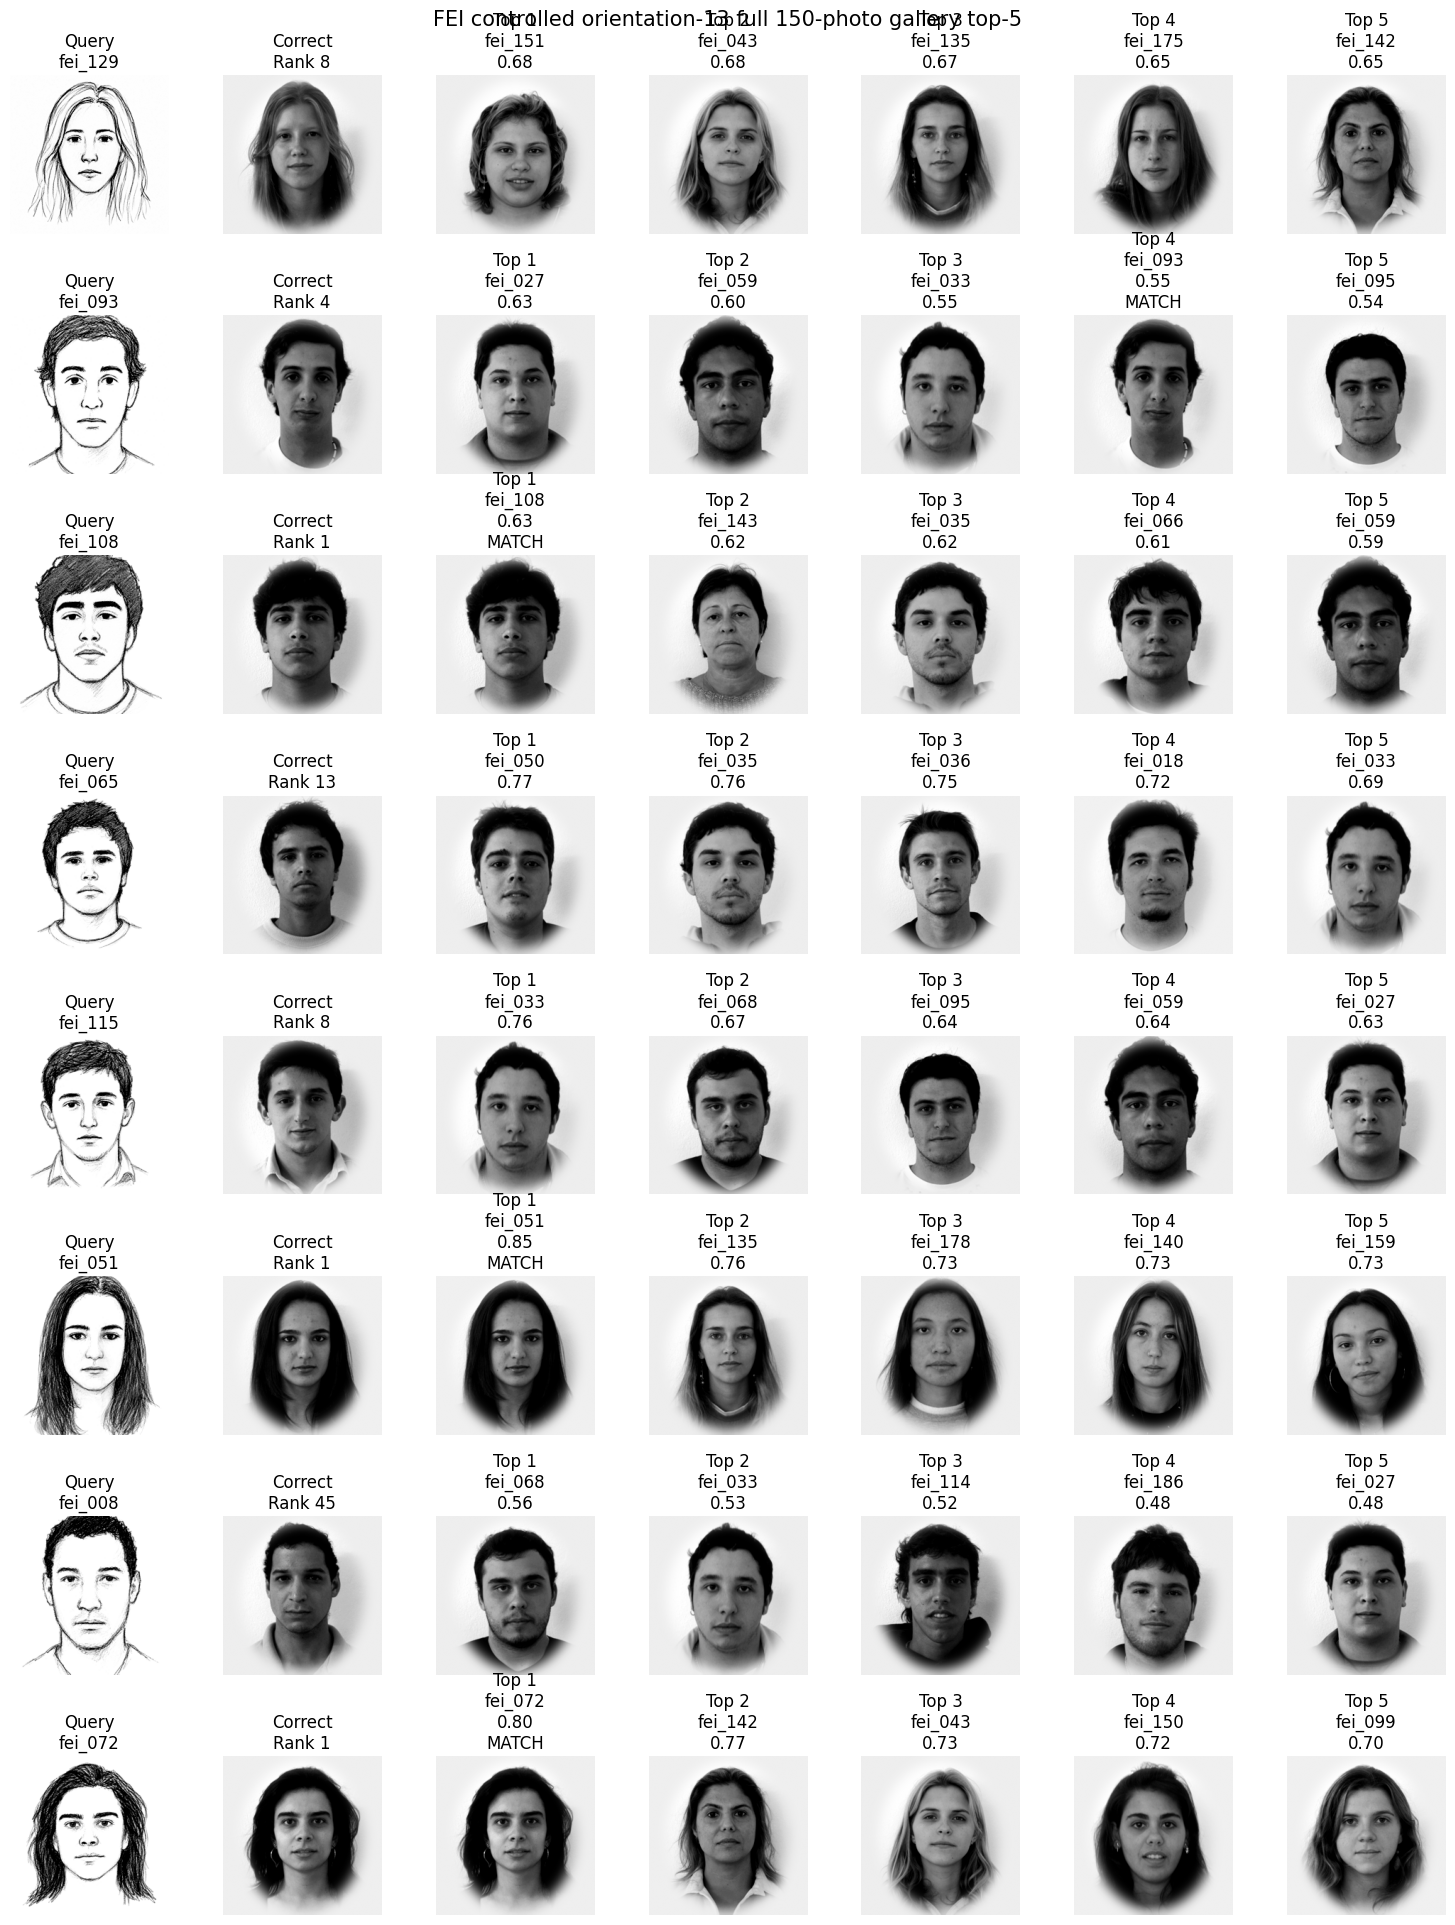

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/multidataset_standardized_resnet18/multidataset_with_fei_full_gallery_results.csv


,split,method,Recall@1,Recall@5,Recall@10,MRR,MeanRank,MedianRank
0,CUFSF test,Multi-dataset standardized ResNet18,0.389121,0.744770,0.878661,0.543531,5.297071,2.0
1,FS2K held-out test,Multi-dataset standardized ResNet18,0.655063,0.901899,0.946203,0.768875,3.430380,1.0
2,FEI centralized full 150-photo gallery,Multi-dataset standardized ResNet18,0.100000,0.400000,0.500000,0.219151,30.950000,11.0
3,FEI controlled orientation-13 full 150-photo g...,Multi-dataset standardized ResNet18,0.250000,0.400000,0.600000,0.342926,19.800000,8.0


In [ ]:

FEI_BEST_MODEL_PATH = MODEL_DIR / 'best_multidataset_standardized_resnet18.pt'

if 'best_model' not in globals():
    if not FEI_BEST_MODEL_PATH.exists():
        raise FileNotFoundError(
            f'Best model checkpoint not found: {FEI_BEST_MODEL_PATH}. Run the training cell once first.'
        )
    best_model = ResNet18ProjectionEncoder(projection_dim=PROJECTION_DIM, pretrained=False).to(DEVICE)
    fei_checkpoint = torch.load(FEI_BEST_MODEL_PATH, map_location=DEVICE)
    best_model.load_state_dict(fei_checkpoint['model_state_dict'])
    best_model.eval()
    print('Loaded best model for FEI evaluation:', FEI_BEST_MODEL_PATH)
    print('Checkpoint epoch:', fei_checkpoint.get('epoch'))

if 'test_results' not in globals():
    previous_results_csv = OUTPUT_DIR / 'multidataset_cufsf_fs2k_test_results.csv'
    if previous_results_csv.exists():
        test_results = pd.read_csv(previous_results_csv)
        print('Loaded previous CUFSF/FS2K test results:', previous_results_csv)
    else:
        test_results = pd.DataFrame()
        print('No previous CUFSF/FS2K test results found; FEI results will be saved alone.')

class ImageOnlyDataset(Dataset):
    def __init__(self, df, path_column, transform):
        self.df = df.reset_index(drop=True).copy()
        self.path_column = path_column
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row[self.path_column]).convert('RGB')
        return {
            'id': str(row['id']),
            'image': self.transform(image),
            'path': row[self.path_column],
        }


@torch.no_grad()
def encode_image_table(model, df, path_column, transform, device=DEVICE):
    dataset = ImageOnlyDataset(df, path_column, transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    ids = []
    embeddings = []
    model.eval()
    for batch in tqdm(loader, desc=f'Encoding {path_column}', leave=False):
        images = batch['image'].to(device, non_blocking=True)
        embeddings.append(model(images).cpu())
        ids.extend([str(x) for x in batch['id']])
    return ids, torch.cat(embeddings, dim=0).numpy()


def evaluate_fei_full_gallery(model, eval_bundle, label):
    query_df = eval_bundle['query_df']
    gallery_df = eval_bundle['gallery_df']
    query_ids, query_embeddings = encode_image_table(model, query_df, 'sketch_path', eval_transform)
    gallery_ids, gallery_embeddings = encode_image_table(model, gallery_df, 'photo_path', eval_transform)
    similarity = query_embeddings @ gallery_embeddings.T
    metrics, ranks = evaluate_similarity_matrix(similarity, query_ids, gallery_ids)

    print(f'\n{label}')
    print('-' * len(label))
    print('Queries:', len(query_ids))
    print('Gallery photos:', len(gallery_ids))
    for key, value in metrics.items():
        if key.startswith('Recall') or key == 'MRR':
            print(f'{key}: {value:.4f}')
        else:
            print(f'{key}: {value:.2f}')

    return metrics, ranks, similarity, query_ids, gallery_ids


def make_fei_full_gallery_grid(query_df, gallery_df, similarity, ranks, method_name, n_examples=8, top_k=5, seed=42, save_path=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(query_df), size=min(n_examples, len(query_df)), replace=False)
    fig, axes = plt.subplots(len(indices), 2 + top_k, figsize=(2.15 * (2 + top_k), 2.45 * len(indices)))
    if len(indices) == 1:
        axes = np.array([axes])

    for row_i, query_idx in enumerate(indices):
        query = query_df.iloc[query_idx]
        ranked = np.argsort(-similarity[query_idx])[:top_k]
        correct_gallery = gallery_df[gallery_df['id'].astype(str) == str(query['id'])].iloc[0]

        axes[row_i, 0].imshow(Image.open(query['sketch_path']).convert('L'), cmap='gray')
        axes[row_i, 0].set_title(f"Query\n{query['id']}")
        axes[row_i, 0].axis('off')

        axes[row_i, 1].imshow(Image.open(correct_gallery['photo_path']).convert('L'), cmap='gray')
        axes[row_i, 1].set_title(f"Correct\nRank {ranks[query_idx]}")
        axes[row_i, 1].axis('off')

        for j, gallery_idx in enumerate(ranked):
            item = gallery_df.iloc[gallery_idx]
            score = similarity[query_idx, gallery_idx]
            is_correct = str(item['id']) == str(query['id'])
            title = f"Top {j + 1}\n{item['id']}\n{score:.2f}"
            if is_correct:
                title += '\nMATCH'
            axes[row_i, 2 + j].imshow(Image.open(item['photo_path']).convert('L'), cmap='gray')
            axes[row_i, 2 + j].set_title(title)
            axes[row_i, 2 + j].axis('off')

    fig.suptitle(method_name, fontsize=15)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Saved:', save_path)
    plt.show()


fei_results = []

if fei_centralized_eval is not None:
    fei_centralized_metrics, fei_centralized_ranks, fei_centralized_similarity, _, _ = evaluate_fei_full_gallery(
        best_model,
        fei_centralized_eval,
        'Multi-dataset model on FEI centralized full 150-photo gallery',
    )
    fei_results.append({
        'split': 'FEI centralized full 150-photo gallery',
        'method': 'Multi-dataset standardized ResNet18',
        **fei_centralized_metrics,
    })
    make_fei_full_gallery_grid(
        fei_centralized_eval['query_df'],
        fei_centralized_eval['gallery_df'],
        fei_centralized_similarity,
        fei_centralized_ranks,
        'FEI centralized full 150-photo gallery top-5',
        n_examples=min(8, len(fei_centralized_eval['query_df'])),
        save_path=RETRIEVAL_DIR / 'fei_centralized_full150_gallery_top5.png',
    )

if fei_controlled_eval is not None:
    fei_controlled_metrics, fei_controlled_ranks, fei_controlled_similarity, _, _ = evaluate_fei_full_gallery(
        best_model,
        fei_controlled_eval,
        'Multi-dataset model on FEI controlled orientation-13 full 150-photo gallery',
    )
    fei_results.append({
        'split': 'FEI controlled orientation-13 full 150-photo gallery',
        'method': 'Multi-dataset standardized ResNet18',
        **fei_controlled_metrics,
    })
    make_fei_full_gallery_grid(
        fei_controlled_eval['query_df'],
        fei_controlled_eval['gallery_df'],
        fei_controlled_similarity,
        fei_controlled_ranks,
        'FEI controlled orientation-13 full 150-photo gallery top-5',
        n_examples=min(8, len(fei_controlled_eval['query_df'])),
        save_path=RETRIEVAL_DIR / 'fei_controlled_full150_gallery_top5.png',
    )

if fei_results:
    all_results = pd.concat([test_results, pd.DataFrame(fei_results)], ignore_index=True)
    all_results_csv = OUTPUT_DIR / 'multidataset_with_fei_full_gallery_results.csv'
    all_results.to_csv(all_results_csv, index=False)
    print('Saved:', all_results_csv)
    display(all_results)
else:
    print('No FEI results yet. Generate sketches into:', FEI_SKETCH_DIR)